In [1]:
%matplotlib inline
import csv
import dataclasses
import importlib
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import pandas as pd
from IPython.display import display

# Resolve the repository whether Jupyter starts in the repo root or figures/.
working_dir = Path.cwd().resolve()
REPO = working_dir.parent if working_dir.name == "figures" else working_dir
if not (REPO / "model.py").is_file():
    REPO = next(
        parent for parent in (working_dir, *working_dir.parents)
        if (parent / "figures").is_dir() and (parent / "model.py").is_file()
    )

FIGURES_DIR = REPO / "figures"
FIGUTIL_DIR = FIGURES_DIR / "figutil"
SOURCE = FIGURES_DIR / "figdata/patient_shap"
CASE_KEY = "death"
CASE_SOURCE = SOURCE / CASE_KEY
LABEL_SOURCE = SOURCE / "labels.csv"
CHAPTER_SOURCE = REPO / "data/labels_chapter.csv"
EXPORT_DIR = FIGURES_DIR / "outputs/patient_shap"
FONT_PATH = FIGUTIL_DIR / "Helvetica.ttf"
BOLD_FONT_PATH = FIGUTIL_DIR / "Helvetica Bold.ttf"

SAVE_FIGURES = True
OVERWRITE_FIGURES = True
TOP_EVENT_SHAP = 12
RISK_LOOKBACK_DAYS = 365
UNIQUE_TOKEN_DISPLAY = False
EVENT_EPISODE_WINDOW_DAYS = 30  # merge repeated identical tokens within this span
RISK_CALLOUTS = (
    {"relative_day": -177, "token": 1174, "offset_points": (-12, 34)},
)

for required in (CASE_SOURCE, LABEL_SOURCE, CHAPTER_SOURCE, FONT_PATH, BOLD_FONT_PATH):
    if not required.exists():
        raise FileNotFoundError(required)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
if str(FIGUTIL_DIR) not in sys.path:
    sys.path.insert(0, str(FIGUTIL_DIR))

import figure_palette
import plot_patient_shap

figure_palette = importlib.reload(figure_palette)
plot_patient_shap = importlib.reload(plot_patient_shap)
load_token_chapter_metadata = figure_palette.load_token_chapter_metadata

with LABEL_SOURCE.open() as handle:
    LABELS = [",".join(row).rstrip(",") for row in csv.reader(handle)]
LABELS += ["Unused", "Female (reference: male)", "Age at prediction (continuous)"]
assert len(LABELS) == 1292
CHAPTER_METADATA = load_token_chapter_metadata(CHAPTER_SOURCE)

for font_path in (FONT_PATH, BOLD_FONT_PATH):
    fm.fontManager.addfont(font_path)
FONT_NAME = fm.FontProperties(fname=FONT_PATH).get_name()
for index, entry in enumerate(fm.fontManager.ttflist):
    if entry.fname == str(BOLD_FONT_PATH):
        fm.fontManager.ttflist[index] = dataclasses.replace(
            entry, name=FONT_NAME, weight=700
        )
plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": 10,
    "mathtext.fontset": "custom",
    "mathtext.rm": FONT_NAME,
    "mathtext.bf": f"{FONT_NAME}:bold",
    "pdf.fonttype": 3,
})

LOW, HIGH, GREY = "#2E76AD", "#C34D60", "#64717C"
print(f"Repository: {REPO}")
print(f"Case: {CASE_KEY}")
print(f"Chapter palette: {FIGUTIL_DIR / 'figure_palette.py'}")
print(f"Export: {'enabled' if SAVE_FIGURES else 'disabled'}")

Repository: /home/hsh/GPT-Disease-Drug-Prediction
Case: death
Chapter palette: /home/hsh/GPT-Disease-Drug-Prediction/figures/figutil/figure_palette.py
Export: enabled


### Load and validate the selected case

In [2]:
def load_case(folder):
    selected = json.loads((folder / "selected.json").read_text())
    package_values = folder / "selected_event_shap_shap_package_q16.npz"
    package_qc = folder / "selected_event_shap_shap_package_q16_qc.json"
    if not package_values.is_file() or not package_qc.is_file():
        raise FileNotFoundError("Official SHAP package artifacts are required")
    event = np.load(package_values)
    event_qc = json.loads(package_qc.read_text())
    history = pd.read_csv(folder / "history_and_outcome.csv")
    predictions = pd.read_csv(folder / "prefix_predictions.csv")
    prediction_qc = json.loads((folder / "prefix_predictions_qc.json").read_text())
    death_tte = json.loads((folder / "death_tte_summary.json").read_text())
    return selected, event, event_qc, history, predictions, prediction_qc, death_tte


selected, event, event_qc, history, predictions, prediction_qc, death_tte = load_case(CASE_SOURCE)
positions = event["event_positions"].astype(int)
tokens = event["event_tokens"].astype(int)
ages = event["event_age_years"].astype(float)
values = event["event_shap"].astype(float)
baseline = float(event["baseline"])
full = float(event["full"])
age_shap = float(event["age_shap"])

assert event_qc["status"] == prediction_qc["status"] == death_tte["status"] == "PASS"
assert event_qc["explainer"] == "shap.PermutationExplainer"
assert len(positions) == len(tokens) == len(ages) == len(values)
assert np.array_equal(history.iloc[positions].token.to_numpy(dtype=int), tokens)
assert np.allclose(history.iloc[positions].age_years.to_numpy(dtype=float), ages)
assert np.all(np.diff(positions) > 0)
assert abs(baseline + values.sum() + age_shap - full) < 1e-8
assert int(history.iloc[-1].token) == 1288
assert int(history.iloc[-1].relative_day) == int(selected["death_gap_days"])
assert int(predictions.anchor_row.iloc[-1]) == int(selected["anchor"])
assert abs(float(predictions.p_death_q256.iloc[-1]) - death_tte["marginal_death_probability"]) < .002
assert death_tte["conditional_tte_q25_days"] <= death_tte["conditional_tte_median_days"] <= death_tte["conditional_tte_q75_days"]
assert abs(
    death_tte["display_marginal_death_probability"]
    - float(predictions.p_death_q16.iloc[-1])
) < 1e-6
assert (
    0 <= death_tte["time_conditioned_death_probability_q25"]
    <= death_tte["time_conditioned_death_probability_median"]
    <= death_tte["time_conditioned_death_probability_q75"] <= 1
)

case = {
    "selected": selected,
    "event": event,
    "event_qc": event_qc,
    "history": history,
    "baseline": baseline,
    "full": full,
    "age_shap": age_shap,
}
summary = pd.DataFrame([{
    "Patient": selected["patient_index"],
    "Final record": LABELS[int(selected["anchor_token"])],
    "P(next event = Death), Q16": predictions.p_death_q16.iloc[-1],
    "TIME-conditioned P median": death_tte["time_conditioned_death_probability_median"],
    "TIME-conditioned P IQR": (
        f'{death_tte["time_conditioned_death_probability_q25"]:.1%}–'
        f'{death_tte["time_conditioned_death_probability_q75"]:.1%}'
    ),
    "Predicted Death TTE median, days": death_tte["conditional_tte_median_days"],
    "Predicted TTE Q25–Q75, days": f'{death_tte["conditional_tte_q25_days"]:.0f}–{death_tte["conditional_tte_q75_days"]:.0f}',
    "Observed Death TTE, days": death_tte["observed_death_gap_days"],
    "Predicted Death age, years": death_tte["predicted_death_age_median_years"],
    "Observed Death age, years": death_tte["observed_death_age_years"],
    "SHAP completeness error": event_qc["completeness_error"],
}])
display(summary.style.format({
    "P(next event = Death), Q16": "{:.1%}",
    "TIME-conditioned P median": "{:.1%}",
    "Predicted Death age, years": "{:.2f}",
    "Observed Death age, years": "{:.2f}",
    "SHAP completeness error": "{:.2e}",
}))


,Patient,Final record,"P(next event = Death), Q16",TIME-conditioned P median,TIME-conditioned P IQR,"Predicted Death TTE median, days","Predicted TTE Q25–Q75, days","Observed Death TTE, days","Predicted Death age, years","Observed Death age, years",SHAP completeness error
0,6217,A41 (other septicaemia),71.8%,78.7%,66.9%–84.6%,15.000000,7–28,27,86.11,86.14,4.44e-16


### Panel A — Death prediction trajectory and timing

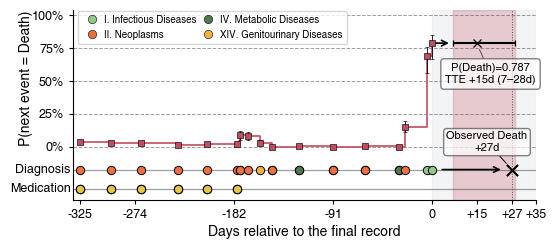

In [3]:
# Layout remains editable here; rendering lives in figutil/plot_patient_shap.py.
FIGSIZE_A = (5, 2.5)
PANEL_A_BOUNDS = (.065, .19, .925, .76)
FUTURE_DISPLAY_WIDTH = 95.0

figure_a = plot_patient_shap.draw_death_prediction_panel(
    case, predictions, death_tte, LABELS, CHAPTER_METADATA,
    figsize=FIGSIZE_A, panel_bounds=PANEL_A_BOUNDS,
    future_display_width=FUTURE_DISPLAY_WIDTH,
    lookback_days=RISK_LOOKBACK_DAYS,
)
panel_a_paths = {}
if SAVE_FIGURES:
    for suffix in ("png", "pdf"):
        output_path = EXPORT_DIR / f"patient_shap_a.{suffix}"
        if output_path.exists() and not OVERWRITE_FIGURES:
            raise FileExistsError(output_path)
        figure_a.savefig(
            output_path, dpi=300, bbox_inches="tight", pad_inches=.02,
            facecolor="white", transparent=False,
        )
        panel_a_paths[suffix] = output_path

display(figure_a)
plt.close(figure_a)

### Panel B — Death SHAP explanation

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


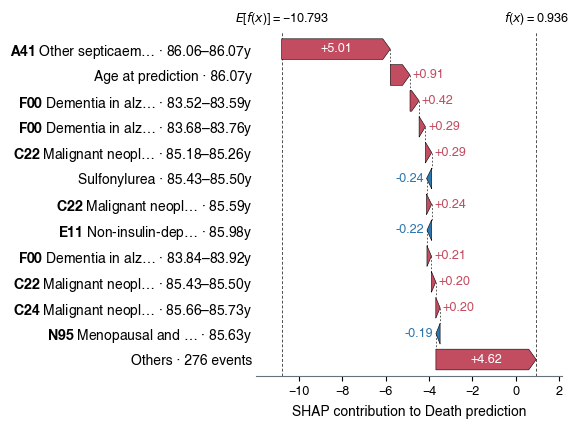

In [4]:
# ---------------------- independently editable Panel B ----------------------
FIGSIZE_B = (6.5, 4.0)
PANEL_B_BOUNDS = [0.50, 0.10, 0.47, 0.86]
# ---------------------------------------------------------------------------

figure_b, death_shown_attributions = plot_patient_shap.draw_shap_panel(
    case,
    labels=LABELS,
    target_label="Death",
    figsize=FIGSIZE_B,
    panel_bounds=PANEL_B_BOUNDS,
    top_n=TOP_EVENT_SHAP,
    episode_window_days=EVENT_EPISODE_WINDOW_DAYS,
    unique_token_display=UNIQUE_TOKEN_DISPLAY,
    resize_figure=False,
)

if SAVE_FIGURES:
    panel_b_paths = {
        "png": EXPORT_DIR / "patient_shap_b.png",
        "pdf": EXPORT_DIR / "patient_shap_b.pdf",
        # "svg": EXPORT_DIR / "patient_shap_b.svg",
    }
    for output_path in panel_b_paths.values():
        if output_path.exists() and not OVERWRITE_FIGURES:
            raise FileExistsError(output_path)
    figure_b.savefig(panel_b_paths["png"], dpi=900, bbox_inches="tight",
                     pad_inches=.02, facecolor="white")
    figure_b.savefig(panel_b_paths["pdf"], bbox_inches="tight",
                     pad_inches=.02, facecolor="white")
else:
    panel_b_paths = {}

display(figure_b)
plt.close(figure_b)

### EVENT case — first-recorded I25 chronic ischaemic heart disease

In [5]:
EVENT_CASE_KEY = "i25"
EVENT_OUTPUT = FIGURES_DIR / "outputs/patient_shap/"
EVENT_OUTPUT.mkdir(parents=True, exist_ok=True)
event_case = plot_patient_shap.load_case(REPO, EVENT_CASE_KEY)
event_selected = event_case["selected"]
event_qc = event_case["case_qc"]
event_timing = event_case["timing"]
event_summary = pd.DataFrame([{
    "Patient": event_selected["patient_index"],
    "Target": event_selected["target_label"],
    "Final input": event_case["labels"][int(event_selected["anchor_token"])],
    "P(target), Q16": event_qc["final_probability_q16"],
    "Rank among clinical events": event_qc["final_rank_q16"],
    "Predicted TTE, median days": event_timing["conditional_tte_median_days"],
    "Predicted TTE IQR, days": f'{event_timing["conditional_tte_q25_days"]:.0f}–{event_timing["conditional_tte_q75_days"]:.0f}',
    "Observed gap, days": event_timing["observed_gap_days"],
    "Official SHAP completeness error": event_case["shap_qc"]["completeness_error"],
}])
display(event_summary.style.format({
    "P(target), Q16": "{:.2%}",
    "Official SHAP completeness error": "{:.2e}",
}))

,Patient,Target,Final input,"P(target), Q16",Rank among clinical events,"Predicted TTE, median days","Predicted TTE IQR, days","Observed gap, days",Official SHAP completeness error
0,622,I25 (chronic ischaemic heart disease),Metformin,14.87%,3,5.000000,3–10,5,1.33e-15


### Event Panel A — Probability trajectory and timing

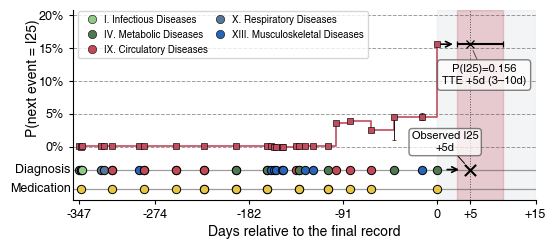

In [6]:
event_figure_a = plot_patient_shap.draw_prediction_panel(
    event_case, figsize=(5, 2.5), panel_bounds=(.065, .19, .925, .76),
    lookback_days=365, future_display_width=95
)
if SAVE_FIGURES:
    plot_patient_shap.save_figure(
        event_figure_a, EVENT_OUTPUT / f"{EVENT_CASE_KEY}_panel_a"
    )
display(event_figure_a)
plt.close(event_figure_a)

### Event Panel B — Official SHAP explanation

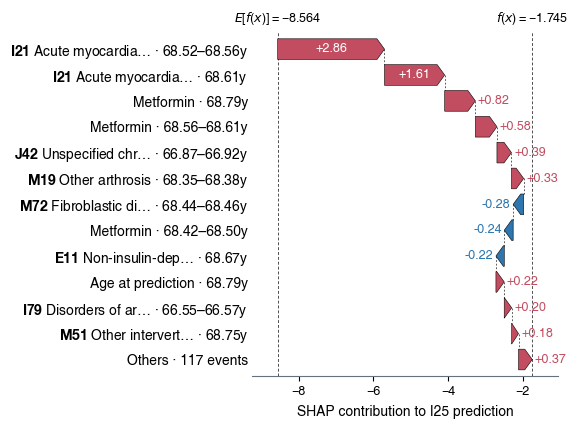

In [7]:
event_figure_b, event_shown_attributions = plot_patient_shap.draw_shap_panel(
    event_case,
    figsize=FIGSIZE_B,
    panel_bounds=PANEL_B_BOUNDS,
    top_n=TOP_EVENT_SHAP,
    episode_window_days=EVENT_EPISODE_WINDOW_DAYS,
    unique_token_display=UNIQUE_TOKEN_DISPLAY,
    resize_figure=False,
)
if SAVE_FIGURES:
    plot_patient_shap.save_figure(
        event_figure_b, EVENT_OUTPUT / f"{EVENT_CASE_KEY}_panel_b"
    )
display(event_figure_b)
plt.close(event_figure_b)